Best k is: 45


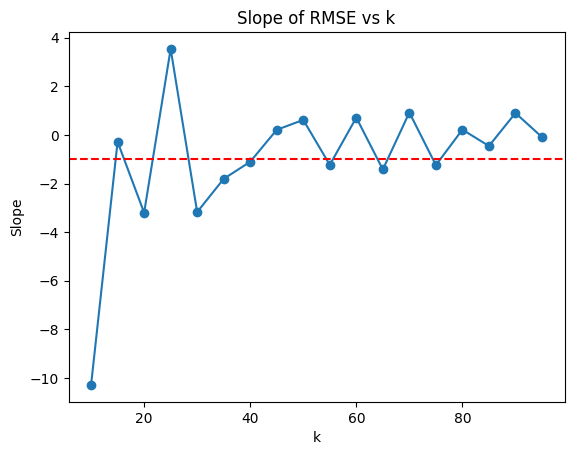

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Get data for k and MSE values
ks = range(10, 105, 5)
mses = {10: np.float64(0.5819755183754586), 15: np.float64(0.29809714904145046), 
20: np.float64(0.2902909942570982), 25: np.float64(0.2019825146042987), 
30: np.float64(0.2996143228475176), 35: np.float64(0.21201014145333502), 
40: np.float64(0.1621252522600909), 45: np.float64(0.1316499985612603), 
50: np.float64(0.13744606272403417), 55: np.float64(0.1544768837991384), 
60: np.float64(0.12044136261975785), 65: np.float64(0.14008067366201815), 
70: np.float64(0.10080972883008701), 75: np.float64(0.12624587105542576), 
80: np.float64(0.09193690120183368), 85: np.float64(0.0979061414143483), 
90: np.float64(0.08530692431161503), 95: np.float64(0.11014746879873467), 
100: np.float64(0.10764834570958784)}
mse_values = [mses[k] for k in ks]

# Compute the normalized values
mse_range = max(mse_values) - min(mse_values)
k_range = max(ks) - min(ks)
mse_values_normalized = [(mse - min(mse_values)) / mse_range for mse in mse_values]
k_normalized = [(k - min(ks)) / k_range for k in ks]

# compute the slope between each pair of consecutive points
slopes = [(mse_values_normalized[i+1] - mse_values_normalized[i]) / (k_normalized[i+1] - k_normalized[i]) for i in range(len(mse_values)-1)]

# find the k value where the slope is over -1 (if we leave out the first few values)
beest_k = None
for i in range(len(slopes)):
    if slopes[i] > -1 and ks[i] != 25 and ks[i] != 15:
        beest_k = ks[i]
        break
print("Best k is:",beest_k)
plt.plot(ks[:-1], slopes, marker='o')
plt.title('Slope of RMSE vs k')
plt.xlabel('k')
plt.ylabel('Slope')
plt.axhline(y=-1, color='r', linestyle='--')
plt.show()

Text(0, 0.5, 'RMSE')

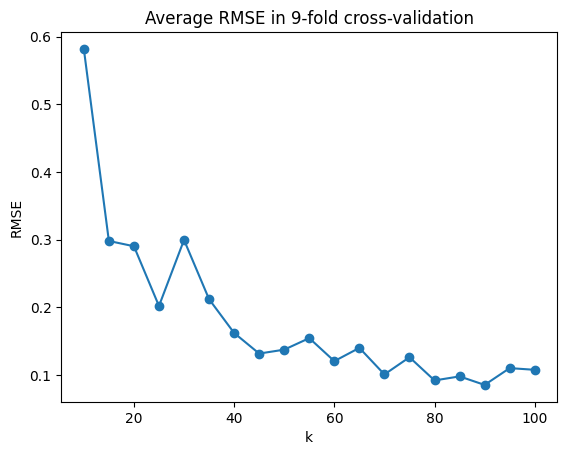

In [11]:
plt.plot(ks, mse_values, marker='o')
plt.title('Average RMSE in 9-fold cross-validation')
plt.xlabel('k')
plt.ylabel('RMSE')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os 

layer_idx = 5
head_idx = 1
num_tokens = 200
path_suffix = 'test'

tag = f"layer_{layer_idx}_head_{head_idx}_tokens_{num_tokens}{path_suffix}"
df = pd.read_csv(f"../../reports/figures/SVD_Nystrom/rank_tuning_all_{tag}.csv")
stats_df = pd.read_csv(f"../../reports/figures/SVD_Nystrom/rank_tuning_stats_{tag}.csv")
df.head()

,company,page,k,rmse
0,Barclays,1,1,0.672795
1,Barclays,1,3,1.381707
2,Barclays,1,5,0.797927
3,Barclays,1,7,0.742021
4,Barclays,1,9,0.941762


In [7]:
import numpy as np
k_list = np.linspace(1, 120, 60, dtype=int).tolist()

n_prompts = len(df) // len(k_list)

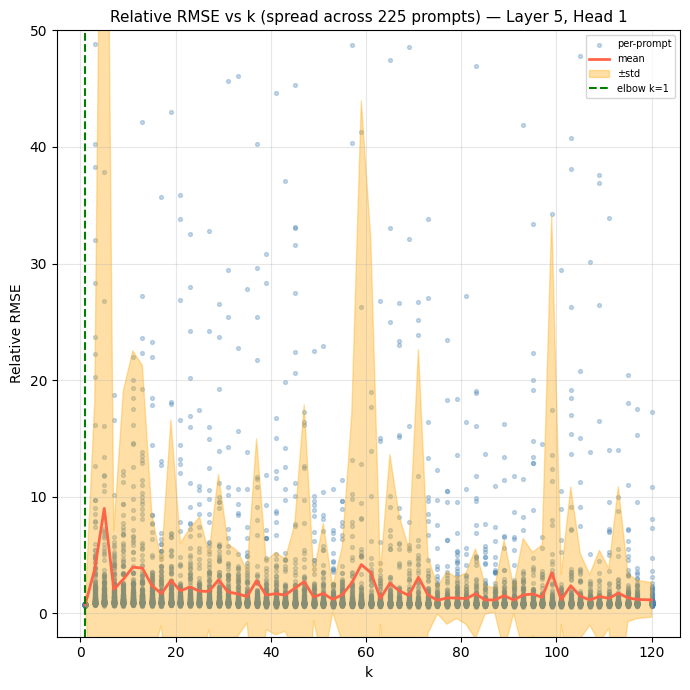

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))
m = stats_df.sort_values("k")
raw = df.sort_values("k")
ax.scatter(raw["k"], raw["rmse"], s=8, alpha=0.3, color="steelblue", label="per-prompt")
ax.plot(m["k"], m["mean"], linewidth=2, color="tomato", label="mean")
ax.fill_between(m["k"], m["mean"] - m["std"], m["mean"] + m["std"], alpha=0.35, color="orange", label="±std")

# Elbow: exclude near-zero plateau, normalize to [0,1], find where slope first rises above -1
ks = m["k"].values.astype(float)
means = m["mean"].values.astype(float)
valid = means > means.max() * 0.01
ks_v, means_v = ks[valid], means[valid]
if len(ks_v) > 1:
    k_range = ks_v.max() - ks_v.min()
    r_range = means_v.max() - means_v.min()
    if k_range > 0 and r_range > 0:
        k_norm = (ks_v - ks_v.min()) / k_range
        r_norm = (means_v - means_v.min()) / r_range
        slopes_norm = np.diff(r_norm) / np.diff(k_norm)
        cross_idx = np.where(slopes_norm >= -1)[0]
        if len(cross_idx) > 0:
            k_cross = int(ks_v[cross_idx[0]])
            ax.axvline(k_cross, color="green", linestyle="--", linewidth=1.5, label=f"elbow k={k_cross}")

ax.set_xlabel("k")
ax.legend(fontsize=7)
ax.tick_params(labelleft=True)
ax.set_title(f"Relative RMSE vs k (spread across {n_prompts} prompts) — Layer {layer_idx}, Head {head_idx}", fontsize=11)
ax.set_ylabel("Relative RMSE")
ax.set_ybound(lower = -2,upper=50)
ax.grid(True, alpha=0.3)
fig.tight_layout()
dist_path = f"reports/figures/SVD_Nystrom/ny_k_distribution_{tag}.pdf"
#fig.savefig(dist_path, dpi=150)
plt.show()
plt.close(fig)
#print(f"Saved: {dist_path}")